# Line-Scan Figures

This notebook plots one-dimensional perturbation scans generated by `run_line.py`. It reads the full dataset when available and falls back to the smoke dataset.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

DATA_DIR = Path("data/line")
plt.rcParams.update({"figure.dpi": 140})

def load_config(dataset_dir):
    with open(dataset_dir / "config.json") as f:
        return json.load(f)

def choose_dataset(data_dir, experiment_name="line"):
    candidates = []
    for dataset_dir in sorted(data_dir.iterdir()) if data_dir.exists() else []:
        if not (dataset_dir / "config.json").exists() or not (dataset_dir / "results.npz").exists():
            continue
        config = load_config(dataset_dir)
        if config.get("experiment_name") != experiment_name:
            continue
        candidates.append(("__smoke" in dataset_dir.name, dataset_dir.stat().st_mtime, dataset_dir.name, dataset_dir, config))
    if not candidates:
        raise FileNotFoundError(f"No {experiment_name} dataset found in {data_dir}. Run python run_line.py first.")
    candidates.sort(key=lambda item: (item[0], -item[1]))
    _, _, name, dataset_dir, config = candidates[0]
    results = np.load(dataset_dir / "results.npz", allow_pickle=False)
    return name, config, results

In [2]:
line_dataset, line_config, line_data = choose_dataset(DATA_DIR)

print("dataset =", line_dataset)
print("experiment =", line_config["experiment_name"])
print("N =", line_config["n"])
print("direction =", line_data["direction"])
print("delta indices =", line_config["delta_indices"])
print("QFI directional =", float(line_data["qfi_directional"]))

dataset = ising1d__tfim__xfield-zfield__plus__line__N10
experiment = line
N = 10
direction = [1. 0.]
delta indices = {'delta_0': 'xfield', 'delta_1': 'zfield'}
QFI directional = 22.114486694335938


## Exact Error And QFIM Prediction

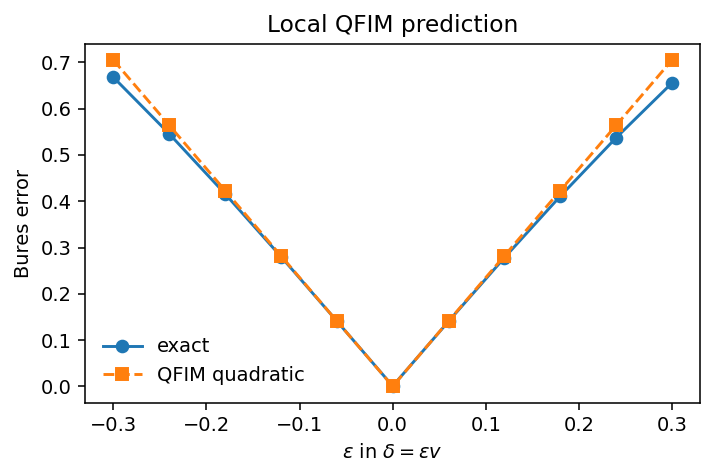

In [3]:
fig, ax = plt.subplots(figsize=(5.2, 3.5))

ax.plot(line_data["epsilons"], line_data["exact_error"], marker="o", label="exact")
ax.plot(line_data["epsilons"], line_data["qfi_error"], marker="s", ls="--", label="QFIM quadratic")
ax.set_xlabel(r"$\epsilon$ in $\delta = \epsilon v$")
ax.set_ylabel("Bures error")
ax.set_title("Local QFIM prediction")
ax.legend(frameon=False)
fig.tight_layout()

## Quadratic Approximation Ratio

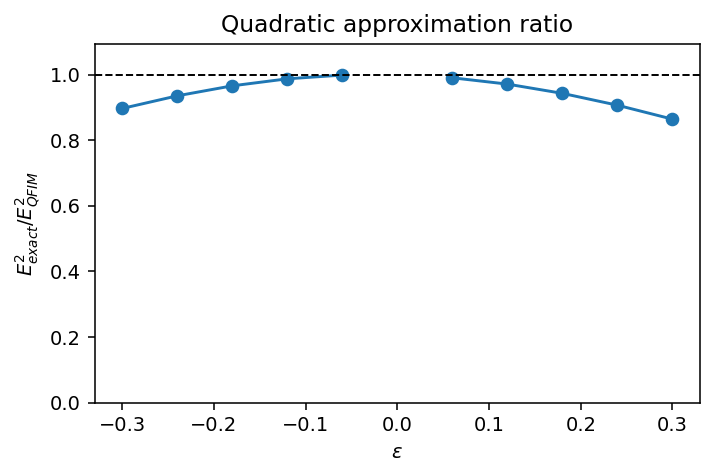

In [4]:
ratio = line_data["ratio"]
finite_ratio = ratio[np.isfinite(ratio)]
ymax = 1.0
if finite_ratio.size:
    ymax = max(1.05, np.nanpercentile(finite_ratio, 95) * 1.1)

fig, ax = plt.subplots(figsize=(5.2, 3.5))
ax.plot(line_data["epsilons"], ratio, marker="o")
ax.axhline(1.0, color="black", lw=1, ls="--")
ax.set_xlabel(r"$\epsilon$")
ax.set_ylabel(r"$E_{exact}^2 / E_{QFIM}^2$")
ax.set_ylim(0, ymax)
ax.set_title("Quadratic approximation ratio")
fig.tight_layout()